# Denoising Diffusion **Gamma** Model (DDGM) on MNIST

## 1. Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
from tqdm import tqdm

## 2. Set device

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f'Using device: {device}')

Using device: cuda


## 3. Hyperparameters

In [3]:
batch_size = 64
image_size = 28
num_epochs = 50
timesteps = 1000
learning_rate = 2e-4
val_epoch = 5
number_test_gen = 16

theta0 = 0.001

## 4. Dataloader configuration

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Scale images to [-1, 1]
])

train_dataset = datasets.MNIST(root='../data',
                               train=True,
                               transform=transform,
                               download=True)

print(f'Size of the training dataset: {len(train_dataset)} samples')

print(f'Train dataset batch size: {batch_size}')

train_dataloader = DataLoader(train_dataset,
                              batch_size=batch_size,
                              shuffle=True)

100%|██████████| 9.91M/9.91M [00:03<00:00, 3.05MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 169kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.30MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 14.0MB/s]

Size of the training dataset: 60000 samples
Train dataset batch size: 64


## 5. Model

In [5]:
class SinusoidalPositionEmbeddings(nn.Module):
    """
    Positional Sinusoidal embeddings (for t)
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time.float()[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings

class Block(nn.Module):
    """
    Downsampling and upsampling block for U-Net
    """
    def __init__(self, in_ch, out_ch, time_emb_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_ch)
        )
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm = nn.GroupNorm(8, out_ch)

    def forward(self, x, t):
        h = self.conv1(x)
        time_emb = self.time_mlp(t)[:, :, None, None]
        h = h + time_emb
        h = self.norm(F.silu(h))
        h = self.conv2(h)
        return self.norm(F.silu(h))

class UNet(nn.Module):
    """
    U-Net for noise estimation (unchanged from DDPM)
    """
    def __init__(self):
        super().__init__()
        time_dim = 32
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_dim),
            nn.Linear(time_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

        self.down1 = Block(1, 64, time_dim)
        self.down2 = Block(64, 128, time_dim)
        self.down3 = Block(128, 256, time_dim)
        self.down4 = Block(256, 512, time_dim)

        self.bottleneck = Block(512, 512, time_dim)  # Keep same channels

        self.up1 = Block(512 + 512, 512, time_dim)  # 512 (bottleneck) + 512 (skip)
        self.up2 = Block(512 + 256, 256, time_dim)
        self.up3 = Block(256 + 128, 128, time_dim)
        self.up4 = Block(128 + 64, 64, time_dim)

        self.final_conv = nn.Conv2d(64, 1, 1)

    def forward(self, x, t):
        t = self.time_mlp(t)

        h1 = self.down1(x, t)  # [B, 64, 28, 28]
        h2 = self.down2(F.avg_pool2d(h1, 2), t)  # [B, 128, 14, 14]
        h3 = self.down3(F.avg_pool2d(h2, 2), t)  # [B, 256, 7, 7]
        h4 = self.down4(F.avg_pool2d(h3, 2), t)  # [B, 512, 3, 3]

        h = self.bottleneck(F.avg_pool2d(h4, 2), t)  # [B, 512, 1, 1]

        h = F.interpolate(h, size=h4.shape[2:], mode='nearest') # [B, 512, 3, 3]
        h = self.up1(torch.cat([h, h4], dim=1), t) # [B, 256, 3, 3]

        h = F.interpolate(h, size=h3.shape[2:], mode='nearest')  # [B, 512, 7, 7]
        h = self.up2(torch.cat([h, h3], dim=1), t) # [B, 256, 7, 7]

        h = F.interpolate(h, size=h2.shape[2:], mode='nearest')  # [B, 256, 14, 14]
        h = self.up3(torch.cat([h, h2], dim=1), t)  # [B, 128, 14, 14]

        h = F.interpolate(h, size=h1.shape[2:], mode='nearest')  # [B, 128, 28, 28]
        h = self.up4(torch.cat([h, h1], dim=1), t)  # [B, 64, 28, 28]

        return self.final_conv(h)  # [B, 1, 28, 28]

class GammaDiffusion:
    """
    Gamma diffusion process (DDGM).

    Forward noise is drawn from a Gamma distribution instead of a Gaussian.
    See Nachmani, San Roman & Wolf (2021), Lemma 1/2 and Algorithm 3/4.
    """
    def __init__(self, timesteps=1000, beta_start=1e-4, beta_end=0.02, theta0=0.001):

        self.timesteps = timesteps
        self.theta0 = theta0

        self.betas = torch.linspace(beta_start, beta_end, timesteps).to(device)
        self.alphas = 1. - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0).to(device)

        self.theta_t = torch.sqrt(self.alpha_bars) * theta0
        self.k_t = self.betas / (self.alpha_bars * theta0 ** 2)
        self.k_bar_t = torch.cumsum(self.k_t, dim=0)

        self.sqrt_alpha_bars = torch.sqrt(self.alpha_bars)
        self.sqrt_one_minus_alpha_bars = torch.sqrt(1. - self.alpha_bars)

        var_gamma = self.k_bar_t * self.theta_t ** 2
        max_err = (var_gamma - (1. - self.alpha_bars)).abs().max().item()
        print(f"[GammaDiffusion] max |V(gbar_t) - (1 - abar_t)| = {max_err:.2e} (should be ~0)")

    def sample_timesteps(self, n):
        return torch.randint(low=1, high=self.timesteps, size=(n,)).to(device)

    def _gamma_noise(self, shape, k_bar, theta):
        """
        Draw zero-mean Gamma noise: g ~ Gamma(shape=k_bar, scale=theta), return g - k_bar*theta.

        k_bar, theta are broadcastable to `shape`. Sampled in float64 because for small theta0
        the Gamma mean (k_bar*theta) is huge (~1e5) while the noise std is ~1, so subtracting the
        mean in float32 loses precision (catastrophic cancellation).
        """
        conc = k_bar.double().expand(shape).contiguous()      # concentration = shape parameter k
        rate = (1.0 / theta).double().expand(shape).contiguous()  # rate = 1 / scale
        g = torch.distributions.Gamma(conc, rate).sample()
        mean = (k_bar * theta).double().expand(shape)
        return g - mean                                       # zero-mean, float64

    def q_sample(self, x0, t):
        """
        Forward diffusion (Eq. 10/12). Returns (x_t, target) where target is the normalized
        noise the network is trained to predict (Lemma 2).
        """
        k_bar = self.k_bar_t[t][:, None, None, None]
        theta = self.theta_t[t][:, None, None, None]
        sqrt_ab = self.sqrt_alpha_bars[t][:, None, None, None]
        sqrt_omab = self.sqrt_one_minus_alpha_bars[t][:, None, None, None]

        noise = self._gamma_noise(x0.shape, k_bar, theta).to(x0.dtype)  # (gbar_t - kbar_t*theta_t)
        x_t = sqrt_ab * x0 + noise                                      # Eq. 10
        target = noise / sqrt_omab                                      # Lemma 2 prediction target
        return x_t, target

    def p_losses(self, denoise_model, x0, t):
        """L1 loss between predicted and (normalized) Gamma noise (Lemma 2)."""
        x_noisy, target = self.q_sample(x0, t)
        predicted = denoise_model(x_noisy, t)
        return F.l1_loss(target, predicted)

@torch.no_grad()
def sample_gamma(model, diffusion, n, image_size, channels=1):
    """
    Gamma inference / sampling (Algorithm 4).

    Differences vs. the Gaussian Algorithm 2:
      (i)  x_T starts from a zero-mean Gamma sample (not N(0, I)),
      (ii) the per-step injected noise z is zero-mean Gamma (normalized to unit variance),
      (iii) the deterministic update is unchanged from DDPM.
    """
    model.eval()
    T = diffusion.timesteps
    shape = (n, channels, image_size, image_size)

    x_t = diffusion._gamma_noise(
        shape,
        diffusion.k_bar_t[T - 1].view(1, 1, 1, 1),
        diffusion.theta_t[T - 1].view(1, 1, 1, 1),
    ).to(device).float()

    for i in reversed(range(0, T)):
        t = torch.full((n,), i, device=device, dtype=torch.long)
        predicted_noise = model(x_t, t)

        alpha = diffusion.alphas[i]
        beta = diffusion.betas[i]
        sqrt_omab = diffusion.sqrt_one_minus_alpha_bars[i]

        x_t = (x_t - (1 - alpha) / sqrt_omab * predicted_noise) / torch.sqrt(alpha)

        if i > 0:
            z = diffusion._gamma_noise(
                shape,
                diffusion.k_bar_t[i - 1].view(1, 1, 1, 1),
                diffusion.theta_t[i - 1].view(1, 1, 1, 1),
            ).to(device).float()
            z = z / diffusion.sqrt_one_minus_alpha_bars[i - 1]
            sigma_t = torch.sqrt(beta)  # as in DDPM / Song et al. (sigma_t^2 = beta_t)
            x_t = x_t + sigma_t * z

    return x_t

def plot_images(images, epoch):
    """
    Plot a grid of generated images
    """
    plt.figure(figsize=(12, 3))
    for i in range(len(images)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(images[i].permute(1, 2, 0).cpu().numpy(), cmap='gray')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

## 6. Initialize models

In [6]:
model = UNet().to(device)
diffusion = GammaDiffusion(timesteps=timesteps, theta0=theta0)

optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-4)  # Added weight decay

scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

[GammaDiffusion] max |V(gbar_t) - (1 - abar_t)| = 9.54e-07 (should be ~0)


## 7. Training

Epoch 0, Loss: 0.0926: 100%|██████████| 938/938 [00:33<00:00, 28.35it/s]


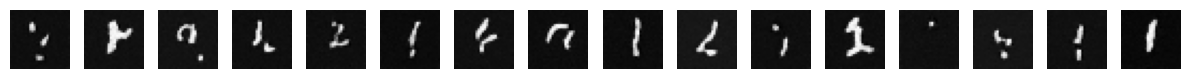

Epoch 0 | Avg Loss: 0.1183 | LR: 2.00e-04


Epoch 1, Loss: 0.0643: 100%|██████████| 938/938 [00:32<00:00, 29.23it/s]


Epoch 1 | Avg Loss: 0.0768 | LR: 1.99e-04


Epoch 2, Loss: 0.0780: 100%|██████████| 938/938 [00:31<00:00, 29.51it/s]


Epoch 2 | Avg Loss: 0.0679 | LR: 1.98e-04


Epoch 3, Loss: 0.0692: 100%|██████████| 938/938 [00:31<00:00, 29.63it/s]


Epoch 3 | Avg Loss: 0.0638 | LR: 1.97e-04


Epoch 4, Loss: 0.0587: 100%|██████████| 938/938 [00:31<00:00, 29.59it/s]


Epoch 4 | Avg Loss: 0.0602 | LR: 1.95e-04


Epoch 5, Loss: 0.0611: 100%|██████████| 938/938 [00:32<00:00, 29.16it/s]


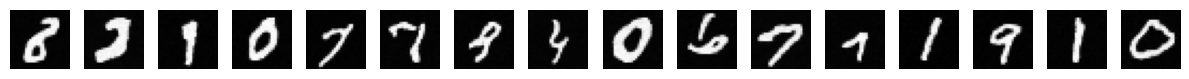

Epoch 5 | Avg Loss: 0.0587 | LR: 1.93e-04


Epoch 6, Loss: 0.0457: 100%|██████████| 938/938 [00:33<00:00, 28.39it/s]


Epoch 6 | Avg Loss: 0.0572 | LR: 1.90e-04


Epoch 7, Loss: 0.0571: 100%|██████████| 938/938 [00:34<00:00, 26.89it/s]


Epoch 7 | Avg Loss: 0.0552 | LR: 1.88e-04


Epoch 8, Loss: 0.0421: 100%|██████████| 938/938 [00:33<00:00, 28.08it/s]


Epoch 8 | Avg Loss: 0.0545 | LR: 1.84e-04


Epoch 9, Loss: 0.0695: 100%|██████████| 938/938 [00:33<00:00, 28.10it/s]


Epoch 9 | Avg Loss: 0.0537 | LR: 1.81e-04


Epoch 10, Loss: 0.0444: 100%|██████████| 938/938 [00:34<00:00, 27.51it/s]


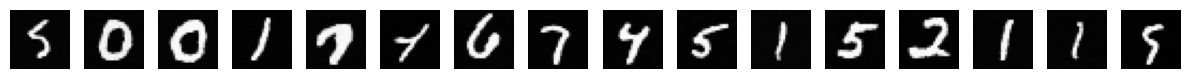

Epoch 10 | Avg Loss: 0.0530 | LR: 1.77e-04


Epoch 11, Loss: 0.0652: 100%|██████████| 938/938 [00:32<00:00, 28.91it/s]


Epoch 11 | Avg Loss: 0.0522 | LR: 1.73e-04


Epoch 12, Loss: 0.0488: 100%|██████████| 938/938 [00:32<00:00, 28.44it/s]


Epoch 12 | Avg Loss: 0.0517 | LR: 1.68e-04


Epoch 13, Loss: 0.0502: 100%|██████████| 938/938 [00:34<00:00, 27.18it/s]


Epoch 13 | Avg Loss: 0.0512 | LR: 1.64e-04


Epoch 14, Loss: 0.0491: 100%|██████████| 938/938 [00:34<00:00, 27.48it/s]


Epoch 14 | Avg Loss: 0.0503 | LR: 1.59e-04


Epoch 15, Loss: 0.0520: 100%|██████████| 938/938 [00:33<00:00, 27.69it/s]


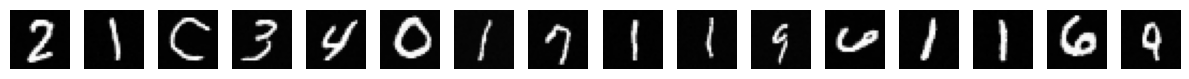

Epoch 15 | Avg Loss: 0.0489 | LR: 1.54e-04


Epoch 16, Loss: 0.0453: 100%|██████████| 938/938 [00:33<00:00, 27.62it/s]


Epoch 16 | Avg Loss: 0.0497 | LR: 1.48e-04


Epoch 17, Loss: 0.0493: 100%|██████████| 938/938 [00:34<00:00, 27.40it/s]


Epoch 17 | Avg Loss: 0.0487 | LR: 1.43e-04


Epoch 18, Loss: 0.0445: 100%|██████████| 938/938 [00:34<00:00, 27.24it/s]


Epoch 18 | Avg Loss: 0.0480 | LR: 1.37e-04


Epoch 19, Loss: 0.0404: 100%|██████████| 938/938 [00:34<00:00, 27.48it/s]


Epoch 19 | Avg Loss: 0.0475 | LR: 1.31e-04


Epoch 20, Loss: 0.0486: 100%|██████████| 938/938 [00:34<00:00, 27.39it/s]


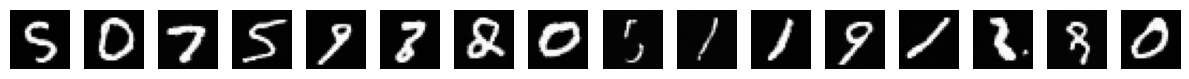

Epoch 20 | Avg Loss: 0.0476 | LR: 1.25e-04


Epoch 21, Loss: 0.0520: 100%|██████████| 938/938 [00:33<00:00, 27.68it/s]


Epoch 21 | Avg Loss: 0.0467 | LR: 1.19e-04


Epoch 22, Loss: 0.0498: 100%|██████████| 938/938 [00:32<00:00, 28.76it/s]


Epoch 22 | Avg Loss: 0.0464 | LR: 1.13e-04


Epoch 23, Loss: 0.0389: 100%|██████████| 938/938 [00:33<00:00, 28.28it/s]


Epoch 23 | Avg Loss: 0.0460 | LR: 1.06e-04


Epoch 24, Loss: 0.0428: 100%|██████████| 938/938 [00:32<00:00, 28.52it/s]


Epoch 24 | Avg Loss: 0.0455 | LR: 1.00e-04


Epoch 25, Loss: 0.0410: 100%|██████████| 938/938 [00:32<00:00, 29.01it/s]


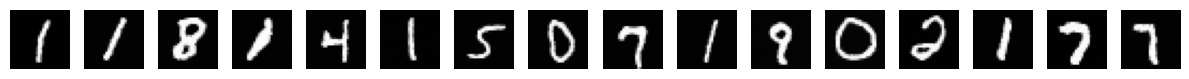

Epoch 25 | Avg Loss: 0.0451 | LR: 9.37e-05


Epoch 26, Loss: 0.0419: 100%|██████████| 938/938 [00:32<00:00, 28.99it/s]


Epoch 26 | Avg Loss: 0.0449 | LR: 8.75e-05


Epoch 27, Loss: 0.0431: 100%|██████████| 938/938 [00:32<00:00, 28.96it/s]


Epoch 27 | Avg Loss: 0.0442 | LR: 8.13e-05


Epoch 28, Loss: 0.0534: 100%|██████████| 938/938 [00:32<00:00, 28.92it/s]


Epoch 28 | Avg Loss: 0.0442 | LR: 7.51e-05


Epoch 29, Loss: 0.0370: 100%|██████████| 938/938 [00:32<00:00, 28.97it/s]


Epoch 29 | Avg Loss: 0.0440 | LR: 6.91e-05


Epoch 30, Loss: 0.0382: 100%|██████████| 938/938 [00:32<00:00, 28.90it/s]


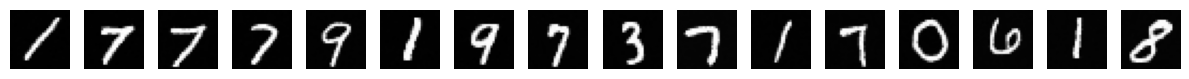

Epoch 30 | Avg Loss: 0.0437 | LR: 6.32e-05


Epoch 31, Loss: 0.0452: 100%|██████████| 938/938 [00:32<00:00, 29.00it/s]


Epoch 31 | Avg Loss: 0.0434 | LR: 5.74e-05


Epoch 32, Loss: 0.0472: 100%|██████████| 938/938 [00:32<00:00, 28.94it/s]


Epoch 32 | Avg Loss: 0.0430 | LR: 5.18e-05


Epoch 33, Loss: 0.0495: 100%|██████████| 938/938 [00:32<00:00, 29.02it/s]


Epoch 33 | Avg Loss: 0.0428 | LR: 4.64e-05


Epoch 34, Loss: 0.0516: 100%|██████████| 938/938 [00:32<00:00, 28.74it/s]


Epoch 34 | Avg Loss: 0.0426 | LR: 4.12e-05


Epoch 35, Loss: 0.0507: 100%|██████████| 938/938 [00:32<00:00, 28.46it/s]


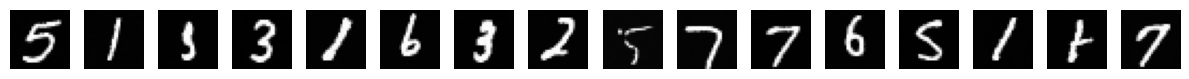

Epoch 35 | Avg Loss: 0.0423 | LR: 3.63e-05


Epoch 36, Loss: 0.0338: 100%|██████████| 938/938 [00:32<00:00, 28.54it/s]


Epoch 36 | Avg Loss: 0.0420 | LR: 3.15e-05


Epoch 37, Loss: 0.0493: 100%|██████████| 938/938 [00:32<00:00, 28.63it/s]


Epoch 37 | Avg Loss: 0.0419 | LR: 2.71e-05


Epoch 38, Loss: 0.0505: 100%|██████████| 938/938 [00:32<00:00, 28.72it/s]


Epoch 38 | Avg Loss: 0.0417 | LR: 2.29e-05


Epoch 39, Loss: 0.0356: 100%|██████████| 938/938 [00:32<00:00, 28.67it/s]


Epoch 39 | Avg Loss: 0.0417 | LR: 1.91e-05


Epoch 40, Loss: 0.0427: 100%|██████████| 938/938 [00:32<00:00, 28.77it/s]


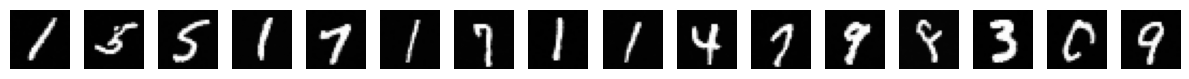

Epoch 40 | Avg Loss: 0.0415 | LR: 1.56e-05


Epoch 41, Loss: 0.0425: 100%|██████████| 938/938 [00:32<00:00, 28.68it/s]


Epoch 41 | Avg Loss: 0.0415 | LR: 1.24e-05


Epoch 42, Loss: 0.0407: 100%|██████████| 938/938 [00:32<00:00, 28.64it/s]


Epoch 42 | Avg Loss: 0.0410 | LR: 9.52e-06


Epoch 43, Loss: 0.0420: 100%|██████████| 938/938 [00:32<00:00, 28.78it/s]


Epoch 43 | Avg Loss: 0.0412 | LR: 7.02e-06


Epoch 44, Loss: 0.0459: 100%|██████████| 938/938 [00:32<00:00, 28.86it/s]


Epoch 44 | Avg Loss: 0.0410 | LR: 4.89e-06


Epoch 45, Loss: 0.0295: 100%|██████████| 938/938 [00:32<00:00, 28.88it/s]


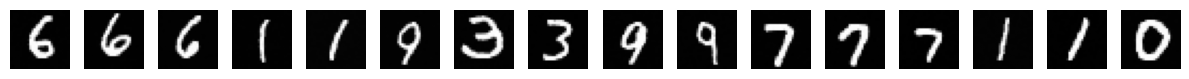

Epoch 45 | Avg Loss: 0.0409 | LR: 3.14e-06


Epoch 46, Loss: 0.0497: 100%|██████████| 938/938 [00:32<00:00, 28.80it/s]


Epoch 46 | Avg Loss: 0.0408 | LR: 1.77e-06


Epoch 47, Loss: 0.0469: 100%|██████████| 938/938 [00:32<00:00, 28.83it/s]


Epoch 47 | Avg Loss: 0.0408 | LR: 7.89e-07


Epoch 48, Loss: 0.0506: 100%|██████████| 938/938 [00:32<00:00, 28.87it/s]


Epoch 48 | Avg Loss: 0.0411 | LR: 1.97e-07


Epoch 49, Loss: 0.0309: 100%|██████████| 938/938 [00:32<00:00, 28.86it/s]


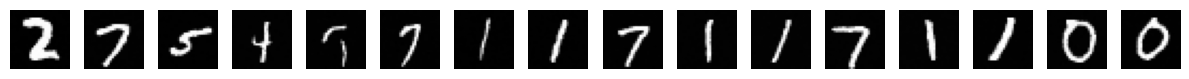

Epoch 49 | Avg Loss: 0.0409 | LR: 0.00e+00


In [7]:
train_loss = []

for epoch in range(num_epochs):

    model.train()
    pbar = tqdm(train_dataloader)
    total_loss = 0

    for images, _ in pbar:

        images = images.to(device)

        t = diffusion.sample_timesteps(images.shape[0])

        loss = diffusion.p_losses(model, images, t)

        optimizer.zero_grad()

        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), 1.0)  # Gradient clipping
        optimizer.step()

        total_loss += loss.item()
        pbar.set_description(f"Epoch {epoch}, Loss: {loss.item():.4f}")

        train_loss.append(loss.item())

    scheduler.step()

    if epoch % val_epoch == 0 or epoch == num_epochs - 1:
        model.eval()
        with torch.no_grad():
            img = sample_gamma(model, diffusion, number_test_gen, image_size)
            plot_images(img, epoch)

    print(f"Epoch {epoch} | Avg Loss: {total_loss/len(train_dataloader):.4f} | LR: {scheduler.get_last_lr()[0]:.2e}")